# Chuong 3: Feature Engineering Pipeline
**Nhom 11**

**Noi dung:**
- Label Encode categorical
- Drop missing > 60%
- Ratio features (9)
- EXT_SOURCE interactions (~25)
- Target Encoding Bayesian (~32)
- QuantileTransformer
- Hinh 3.7, 3.9

In [1]:
import sys, os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pickle, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.config import *
from src.feature_engineering import build_full_pipeline
from src.utils import setup_plot_style, savefig
setup_plot_style()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Loading merged data...')
df = pd.read_parquet(PROCESSED_DIR / 'df_merged.parquet')
print(f'Input shape: {df.shape}')

Loading merged data...
Input shape: (10000, 169)


## 3.1 Chay Toan Bo Pipeline FE

In [2]:
t0 = time.time()
X, y, feat_cols, imputer, scaler, df_fe = build_full_pipeline(df)
elapsed = time.time() - t0
print(f'FE done in {elapsed:.1f}s')
print(f'X shape: {X.shape}')
print(f'X stats: mean={X.mean():.3f}, std={X.std():.3f}')


FEATURE ENGINEERING PIPELINE
[FE] Encoded 16 categorical columns
[FE] Dropped 25 columns (missing > 60%)
[FE] Built 9 ratio features
[FE] Built 26 EXT_SOURCE interaction features
[FE] Applied Target Encoding for 6 columns + 2 cross features


[FE] Added 3 missing indicator columns

[FE] Features: 169 -> 190 (+21 moi)


[FE] Final features: 186 | Removed 2 zero-variance cols
[FE] X mean=-1.165, std=3.032
FE done in 0.9s
X shape: (10000, 186)
X stats: mean=-1.165, std=3.032


## Hinh 3.7 – QuantileTransformer Truoc & Sau

  [Plot] Saved: d:\credisdrick\figures\fig_3_7_quantile_transform.png


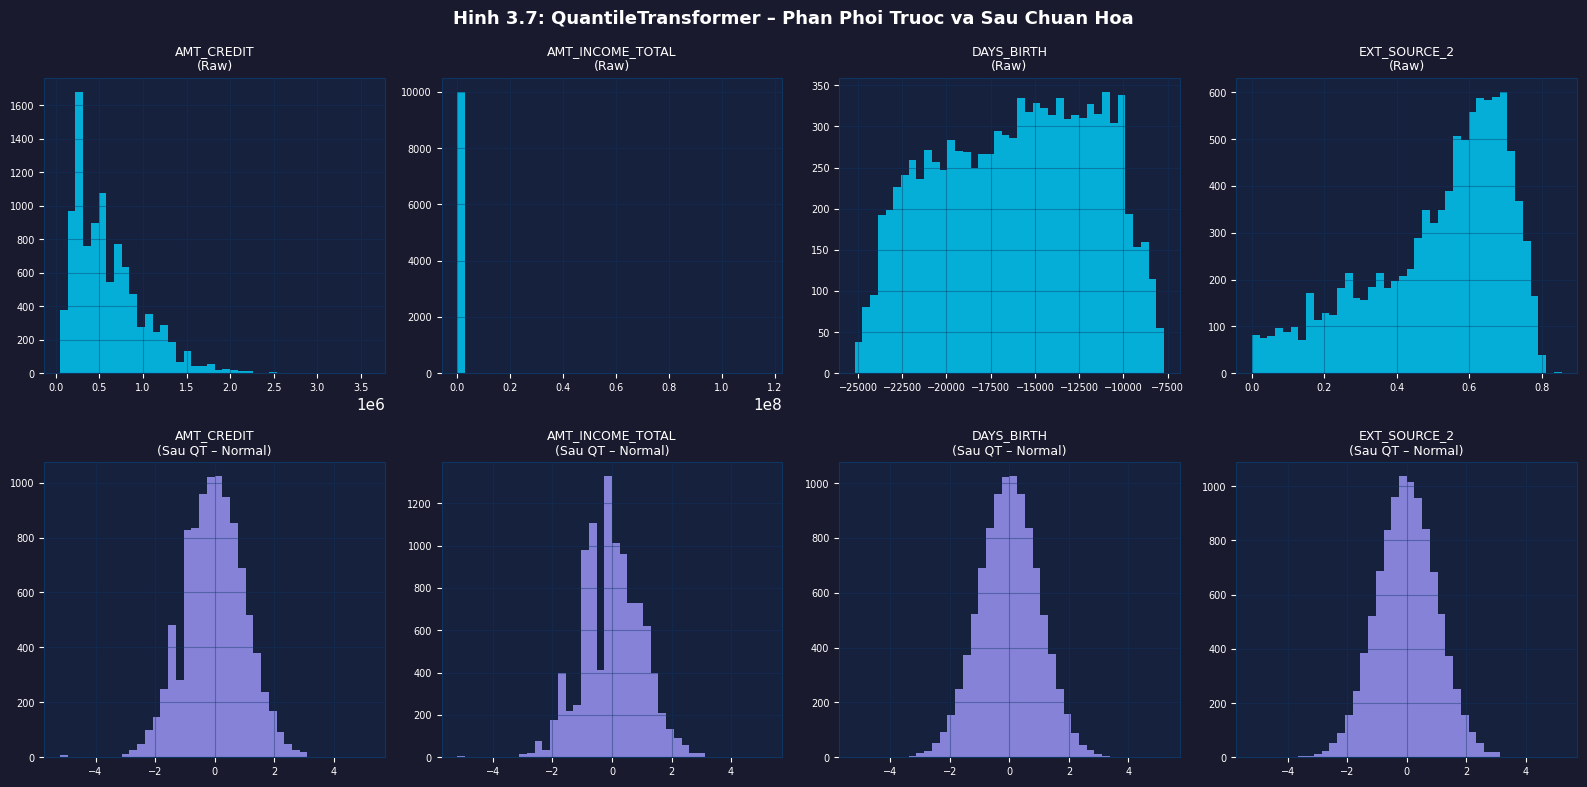

In [3]:
from sklearn.preprocessing import QuantileTransformer as QT
from sklearn.impute import SimpleImputer
demo_cols = [c for c in ['AMT_CREDIT','AMT_INCOME_TOTAL','DAYS_BIRTH','EXT_SOURCE_2'] if c in df.columns]
raw_data  = SimpleImputer(strategy='median').fit_transform(df[demo_cols].values)
qt = QT(output_distribution='normal', n_quantiles=min(500,len(raw_data)), random_state=42)
scaled = qt.fit_transform(raw_data)

fig, axes = plt.subplots(2, len(demo_cols), figsize=(16, 8))
fig.suptitle('Hinh 3.7: QuantileTransformer – Phan Phoi Truoc va Sau Chuan Hoa',
              fontsize=13, fontweight='bold', color='white')
for i, col in enumerate(demo_cols):
    axes[0,i].hist(raw_data[:,i], bins=40, color=PALETTE['normal'], alpha=0.8, edgecolor='none')
    axes[0,i].set_title(f'{col}\n(Raw)', color='white', fontsize=9)
    axes[0,i].set_facecolor('#16213e')
    axes[1,i].hist(scaled[:,i], bins=40, color=PALETTE['ensemble'], alpha=0.8, edgecolor='none')
    axes[1,i].set_title(f'{col}\n(Sau QT – Normal)', color='white', fontsize=9)
    axes[1,i].set_facecolor('#16213e')
for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(colors='white', labelsize=7)
plt.tight_layout()
savefig('fig_3_7_quantile_transform.png')
plt.show()

## Hinh 3.9 – Tang Truong So Features

  [Plot] Saved: d:\credisdrick\figures\fig_3_9_feature_growth.png


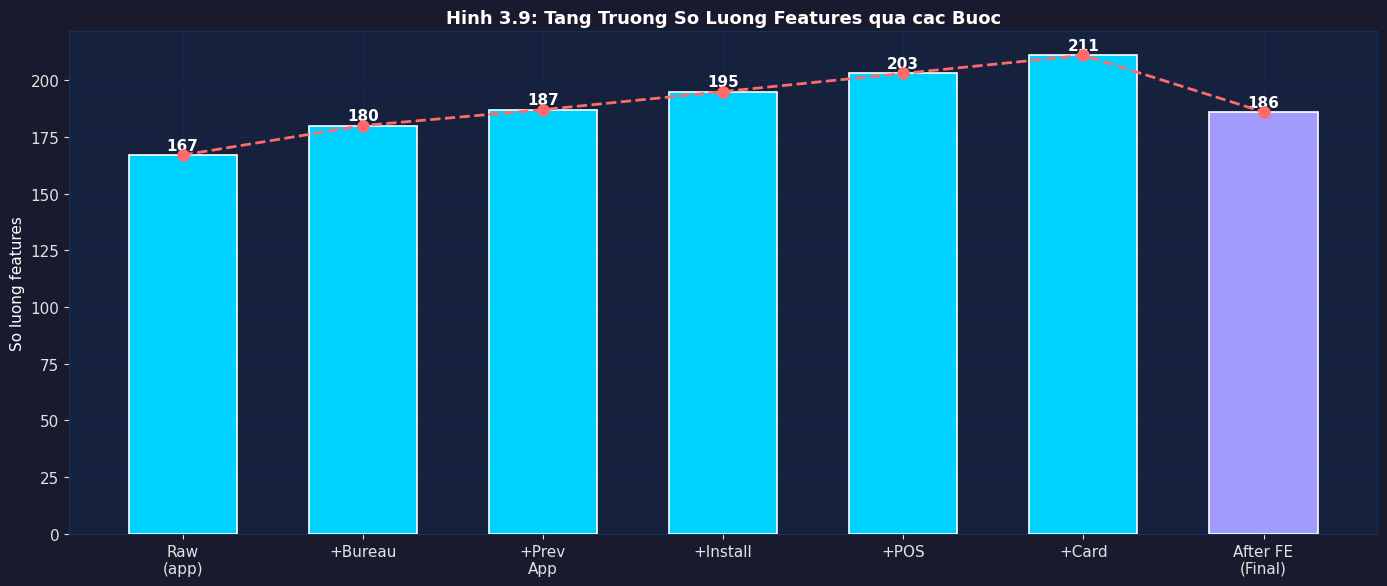

In [4]:
n_base  = df.shape[1] - 2
n_final = X.shape[1]
steps   = ['Raw\n(app)', '+Bureau', '+Prev\nApp', '+Install', '+POS', '+Card', 'After FE\n(Final)']
counts  = [n_base, n_base+13, n_base+20, n_base+28, n_base+36, n_base+44, n_final]
fig, ax = plt.subplots(figsize=(14, 6))
color_bars = [PALETTE['normal']]*6 + [PALETTE['ensemble']]
bars = ax.bar(steps, counts, color=color_bars, edgecolor='white', linewidth=1.2, zorder=3, width=0.6)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             str(cnt), ha='center', va='bottom', fontsize=11, color='white', fontweight='bold')
ax.plot(range(len(steps)), counts, 'o--', color=PALETTE['default'], lw=2, ms=8, zorder=4)
ax.set_title('Hinh 3.9: Tang Truong So Luong Features qua cac Buoc',
              fontsize=13, fontweight='bold', color='white')
ax.set_ylabel('So luong features', color='white')
ax.set_facecolor('#16213e')
plt.tight_layout()
savefig('fig_3_9_feature_growth.png')
plt.show()

## Save Features ra File

In [5]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
np.save(str(PROCESSED_DIR/'X.npy'), X)
np.save(str(PROCESSED_DIR/'y.npy'), y)
with open(PROCESSED_DIR/'feat_cols.pkl','wb') as f: pickle.dump(feat_cols, f)
with open(PROCESSED_DIR/'imputer.pkl','wb') as f:   pickle.dump(imputer, f)
with open(PROCESSED_DIR/'scaler.pkl','wb') as f:    pickle.dump(scaler, f)
print(f'Saved: X{X.shape}, y{y.shape}')
print(f'  feat_cols: {len(feat_cols)} features')
print()
print('=== Notebook 03 HOAN THANH ===')
print('Chay tiep: 04_Task1_CreditRisk.ipynb')

Saved: X(10000, 186), y(10000,)
  feat_cols: 186 features

=== Notebook 03 HOAN THANH ===
Chay tiep: 04_Task1_CreditRisk.ipynb
